In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mean_df = pd.read_csv("./20feat_comparison/curve_mean.csv")
chi_df = pd.read_csv("./20feat_comparison/curve_chi.csv")
summary_df = pd.read_csv("./20feat_comparison/summary.csv")

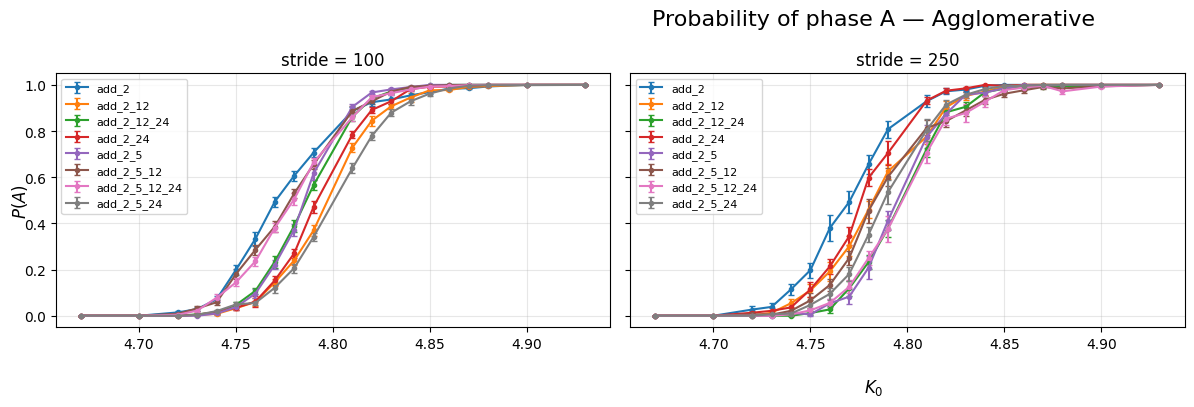

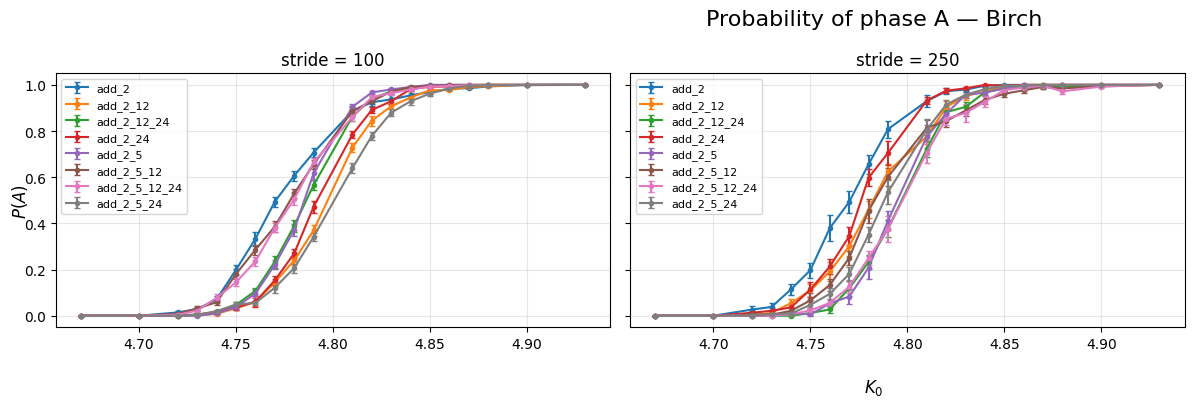

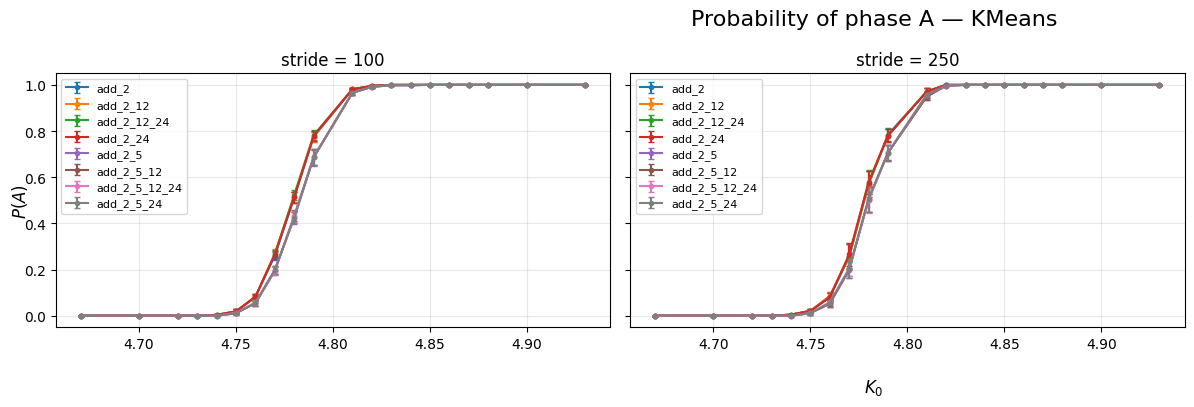

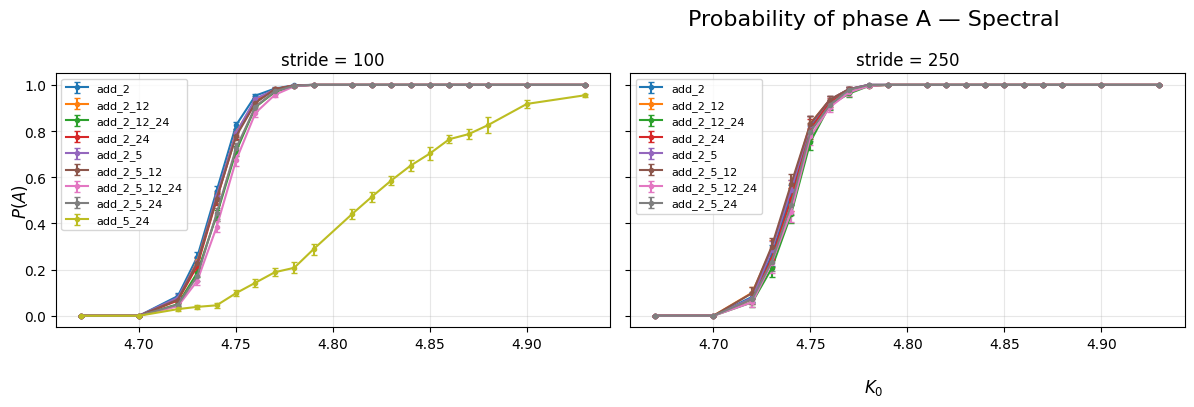

In [2]:
import matplotlib.pyplot as plt

for model, model_df in mean_df.groupby("model"):

    strides = sorted(model_df["stride"].unique())

    ncols = 3
    nrows = int(np.ceil(len(strides) / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6*ncols, 4*nrows),
        sharex=True,
        sharey=True
    )

    axes = np.array(axes).ravel()

    for ax, stride in zip(axes, strides):

        stride_df = model_df[
            model_df["stride"] == stride
        ]

        for feature_set, group in stride_df.groupby("feature_set"):

            if not (group["mean"] > 0.8).any():
                continue
            
            group = group.sort_values("K0")

            ax.errorbar(
                group["K0"],
                group["mean"],
                yerr=group["mean_err"],
                fmt="-o",
                markersize=3,
                capsize=2,
                linewidth=1.5,
                label=feature_set
            )

        ax.set_title(f"stride = {stride}")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    # hide unused axes
    for ax in axes[len(strides):]:
        ax.set_visible(False)

    fig.suptitle(f"Probability of phase A — {model}", fontsize=16)

    fig.supxlabel(r"$K_0$")
    fig.supylabel(r"$P(A)$")

    plt.tight_layout()
    plt.show()

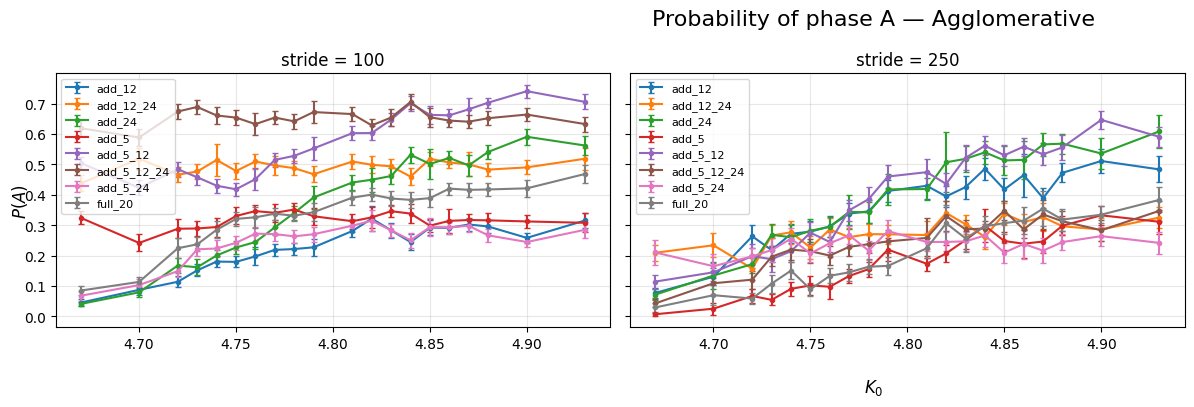

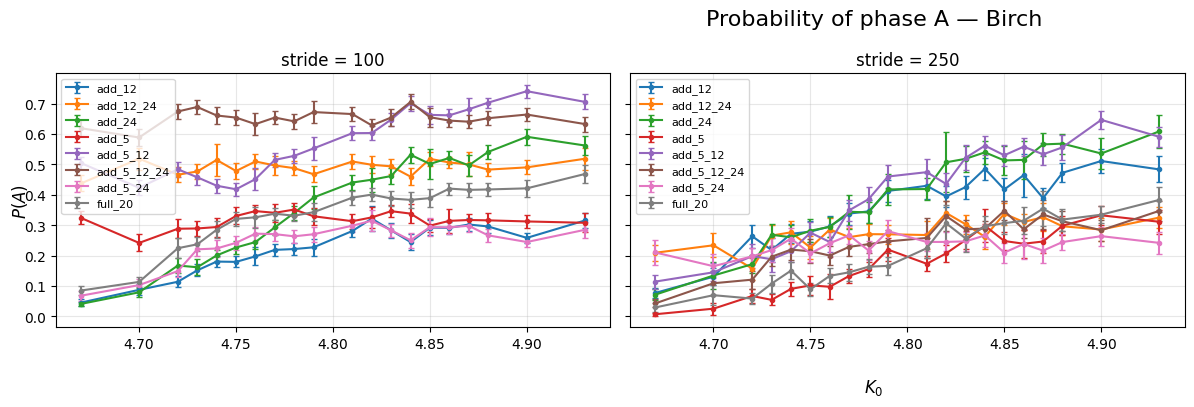

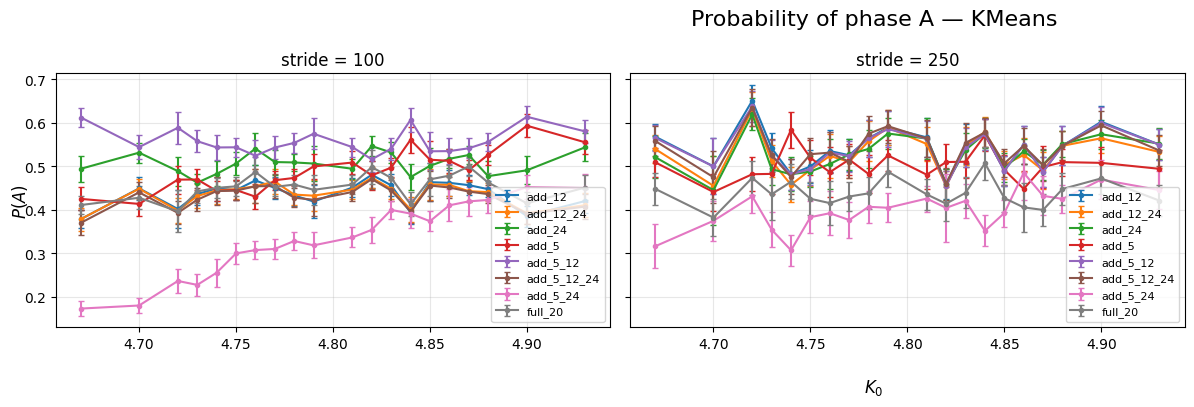

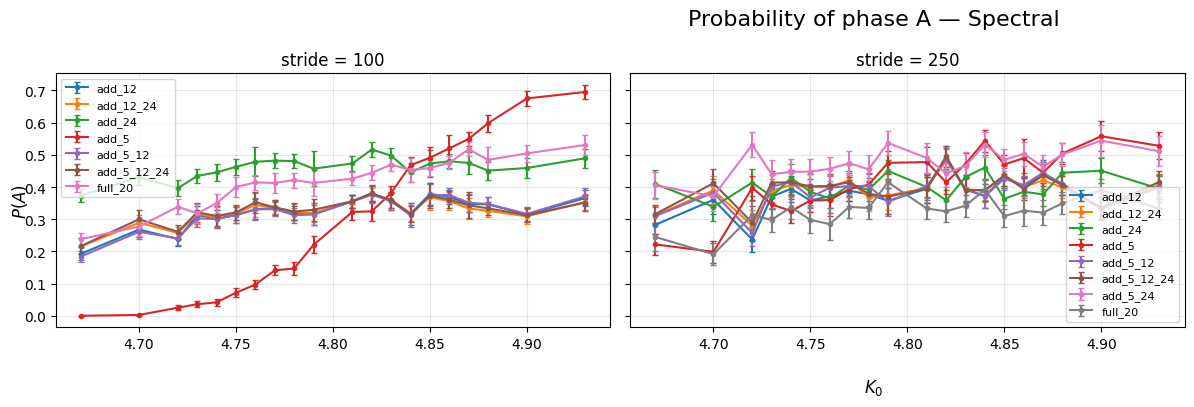

In [3]:
import matplotlib.pyplot as plt

for model, model_df in mean_df.groupby("model"):

    strides = sorted(model_df["stride"].unique())

    ncols = 3
    nrows = int(np.ceil(len(strides) / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6*ncols, 4*nrows),
        sharex=True,
        sharey=True
    )

    axes = np.array(axes).ravel()

    for ax, stride in zip(axes, strides):

        stride_df = model_df[
            model_df["stride"] == stride
        ]

        for feature_set, group in stride_df.groupby("feature_set"):

            if group["mean"].max() >= 0.8:
                continue
            
            group = group.sort_values("K0")

            ax.errorbar(
                group["K0"],
                group["mean"],
                yerr=group["mean_err"],
                fmt="-o",
                markersize=3,
                capsize=2,
                linewidth=1.5,
                label=feature_set
            )

        ax.set_title(f"stride = {stride}")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    # hide unused axes
    for ax in axes[len(strides):]:
        ax.set_visible(False)

    fig.suptitle(f"Probability of phase A — {model}", fontsize=16)

    fig.supxlabel(r"$K_0$")
    fig.supylabel(r"$P(A)$")

    plt.tight_layout()
    plt.show()

In [4]:
kmeans_df = mean_df[
    mean_df["model"] == "KMeans"
]

# feature sets that reach > 0.8 at least once
good_feature_sets = (
    kmeans_df
    .groupby(["stride", "feature_set"])["mean"]
    .max()
    .loc[lambda s: s > 0.8]
    .index
)

table = kmeans_df.set_index(
    ["stride", "feature_set"]
).loc[good_feature_sets].reset_index()

table = table.sort_values(
    ["stride", "feature_set", "K0"]
)

print(table[["stride", "feature_set", "K0", "mean"]].drop_duplicates(subset="mean").sort_values("mean").to_string(index=False))



 stride   feature_set   K0     mean
    100         add_2 4.67 0.000000
    100         add_2 4.74 0.003745
    250         add_2 4.74 0.004717
    100       add_2_5 4.75 0.010903
    250       add_2_5 4.75 0.011628
    100    add_2_5_12 4.75 0.012500
    100         add_2 4.75 0.018750
    250         add_2 4.75 0.020833
    250       add_2_5 4.76 0.052434
    100    add_2_5_12 4.76 0.054348
    250    add_2_5_24 4.76 0.055556
    100 add_2_5_12_24 4.76 0.055738
    100       add_2_5 4.76 0.056250
    250 add_2_5_12_24 4.76 0.059783
    250   add_2_12_24 4.76 0.079787
    100      add_2_12 4.76 0.080000
    100         add_2 4.76 0.081790
    100      add_2_24 4.76 0.083333
    250         add_2 4.76 0.085106
    100 add_2_5_12_24 4.77 0.193362
    100    add_2_5_12 4.77 0.194805
    250       add_2_5 4.77 0.197133
    100    add_2_5_24 4.77 0.197691
    100       add_2_5 4.77 0.199134
    250    add_2_5_24 4.77 0.200717
    250    add_2_5_12 4.77 0.204255
    250         add_2 4.77 0

In [5]:
for model in mean_df["model"].unique():

    plt.figure(figsize=(8, 6))

    subset = mean_df[
        mean_df["model"] == model
    ]

    for calibration, group in subset.groupby(
        "calibration"
    ):

        group = group.sort_values("K0")

        plt.plot(
            group["K0"],
            group["mean"],
            label=calibration
        )

        plt.fill_between(
            group["K0"],
            group["mean"] - group["mean_err"],
            group["mean"] + group["mean_err"],
            alpha=0.2
        )

    plt.xlabel(r"$K_0$")
    plt.ylabel(r"$P(A)$")
    plt.title(model)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    filename = (
        model
        .replace(" ", "_")
        .replace("/", "_")
    )

    # plt.savefig(
    #     f"results/figures/{filename}.png",
    #     dpi=300
    # )

    plt.show()

KeyError: 'calibration'

<Figure size 800x600 with 0 Axes>

In [ ]:
models = list(summary_df["model"].unique())

fig, ax = plt.subplots(
    figsize=(10, 6)
)

# -------------------------
# median wszystkich modeli
# -------------------------

median_kcrit = summary_df["K0_crit"].median()

# zakres wszystkich 1σ
xmin = (
    summary_df["K0_crit"]
    - summary_df["K0_crit_err"]
).min()

xmax = (
    summary_df["K0_crit"]
    + summary_df["K0_crit_err"]
).max()

ax.axvspan(
    xmin,
    xmax,
    alpha=0.15,
    color="red",
    label=r"combined $1\sigma$ range"
)

ax.axvline(
    median_kcrit,
    color="red",
    linestyle="--",
    linewidth=2,
    label="median"
)

# -------------------------
# modele
# -------------------------

for i, model in enumerate(models):

    row_cal = summary_df[
        (summary_df["model"] == model)
        &
        (summary_df["calibration"] == "calibrated")
    ]

    row_uncal = summary_df[
        (summary_df["model"] == model)
        &
        (summary_df["calibration"] == "uncalibrated")
    ]

    if len(row_cal):

        ax.errorbar(
            row_cal["K0_crit"].iloc[0],
            i + 0.12,
            xerr=row_cal["K0_crit_err"].iloc[0],
            fmt="s",
            capsize=5,
            markersize=7,
            color="tab:blue",
            label="calibrated" if i == 0 else None,
        )

    if len(row_uncal):

        ax.errorbar(
            row_uncal["K0_crit"].iloc[0],
            i - 0.12,
            xerr=row_uncal["K0_crit_err"].iloc[0],
            fmt="o",
            capsize=5,
            markersize=7,
            color="tab:red",
            label="uncalibrated" if i == 0 else None,
        )

# -------------------------
# wygląd
# -------------------------

ax.set_yticks(np.arange(len(models)))
ax.set_yticklabels(models)

ax.set_xlabel(
    r"$K_{0,\mathrm{crit}}$"
)

ax.set_title(
    r"Comparison of $K_{0,\mathrm{crit}}$ estimates"
)

ax.grid(
    axis="x",
    alpha=0.3
)

ax.legend()

plt.tight_layout()

# plt.savefig(
#     "results/figures/k0_crit_comparison.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

####pasek reweighting

In [ ]:
print(
    summary_df[
        [
            "model",
            "calibration",
            "K0_crit",
            "K0_crit_err",
        ]
    ].to_latex(
        index=False,
        float_format="%.5f"
    )
)

In [ ]:
feature_sets = ["30", "21", "12"]
models = list(summary_df["model"].unique())

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 6),
    sharey=True
)

for ax, feature in zip(axes, feature_sets):

    df_feat = summary_df[
        summary_df["feature_set"] == feature
    ]

    median_kcrit = df_feat["K0_crit"].median()

    xmin = (
        df_feat["K0_crit"]
        - df_feat["K0_crit_err"]
    ).min()

    xmax = (
        df_feat["K0_crit"]
        + df_feat["K0_crit_err"]
    ).max()

    ax.axvspan(
        xmin,
        xmax,
        alpha=0.15,
        color="red"
    )

    ax.axvline(
        median_kcrit,
        color="red",
        linestyle="--",
        linewidth=2
    )

    for i, model in enumerate(models):

        row_cal = df_feat[
            (df_feat["model"] == model)
            &
            (df_feat["calibration"] == "calibrated")
        ]

        row_uncal = df_feat[
            (df_feat["model"] == model)
            &
            (df_feat["calibration"] == "uncalibrated")
        ]

        if len(row_cal):

            ax.errorbar(
                row_cal["K0_crit"].iloc[0],
                i + 0.12,
                xerr=row_cal["K0_crit_err"].iloc[0],
                fmt="s",
                color="tab:blue",
                capsize=4,
                markersize=6,
            )

        if len(row_uncal):

            ax.errorbar(
                row_uncal["K0_crit"].iloc[0],
                i - 0.12,
                xerr=row_uncal["K0_crit_err"].iloc[0],
                fmt="o",
                color="tab:red",
                capsize=4,
                markersize=6,
            )

    ax.set_title(
        f"{feature} features"
    )

    ax.grid(
        axis="x",
        alpha=0.3
    )

    ax.set_xlabel(
        r"$K_{0,\mathrm{crit}}$"
    )

axes[0].set_yticks(
    np.arange(len(models))
)

axes[0].set_yticklabels(
    models
)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        marker='s',
        color='tab:blue',
        linestyle='None',
        label='calibrated'
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='tab:red',
        linestyle='None',
        label='uncalibrated'
    ),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=2
)
plt.suptitle(
    r"Comparison of $K_{0,\mathrm{crit}}$ estimates"
)

plt.tight_layout()
plt.show()